<a href="https://colab.research.google.com/github/Anit-K-T/Heart-Attack-Prediction/blob/main/code/heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement

 With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.


In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/Patients Data ( Used for Heart Disease Prediction ) (1).csv', encoding='latin1')
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
ÿPatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['State'].value_counts()

,count
State,
Washington,14241
Maryland,8817
Minnesota,8712
Ohio,8700
New York,8625
Texas,7267
Florida,7124
Kansas,6000
Wisconsin,5890


In [ ]:
df['Sex'].value_counts()

,count
Sex,
Female,123293
Male,114337


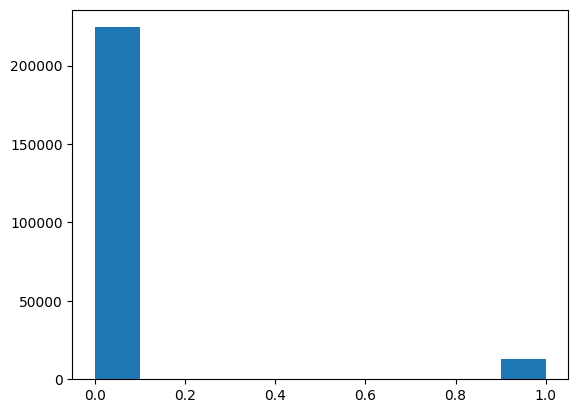

In [ ]:
plt.hist(df['HadHeartAttack'])
plt.show()

In [ ]:
df['GeneralHealth'].unique()

array(['Fair', 'Very good', 'Excellent', 'Good', 'Poor'], dtype=object)

In [ ]:
df['TetanusLast10Tdap'].unique()

array(['No, did not receive any tetanus shot in the past 10 years',
       'Yes, received Tdap',
       'Yes, received tetanus shot but not sure what type',
       'Yes, received tetanus shot, but not Tdap'], dtype=object)

In [ ]:
df['ECigaretteUsage'].unique()

array(['Never used e-cigarettes in my entire life',
       'Not at all (right now)', 'Use them some days',
       'Use them every day'], dtype=object)

In [ ]:
df['RaceEthnicityCategory'].unique()

array(['White only, Non-Hispanic', 'Black only, Non-Hispanic',
       'Other race only, Non-Hispanic', 'Multiracial, Non-Hispanic',
       'Hispanic'], dtype=object)

In [ ]:
df['AgeCategory'].unique()

array(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74',
       'Age 50 to 54', 'Age 80 or older', 'Age 55 to 59', 'Age 25 to 29',
       'Age 40 to 44', 'Age 30 to 34', 'Age 35 to 39', 'Age 18 to 24',
       'Age 45 to 49'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['State']=le.fit_transform(df['State'])
df['Sex']=le.fit_transform(df['Sex'])
df['GeneralHealth'].replace(['Excellent','Very good','Good','Fair','Poor'],[5,4,3,2,1],inplace=True)
df['TetanusLast10Tdap'].replace(['No, did not receive any tetanus shot in the past 10 years',
       'Yes, received Tdap',
       'Yes, received tetanus shot but not sure what type',
       'Yes, received tetanus shot, but not Tdap'],[4,1,3,2],inplace=True)
df['ECigaretteUsage'].replace(['Never used e-cigarettes in my entire life',
       'Not at all (right now)', 'Use them some days',
       'Use them every day'],[1,2,3,4],inplace=True)
df['RaceEthnicityCategory'].replace(['White only, Non-Hispanic', 'Black only, Non-Hispanic',
       'Other race only, Non-Hispanic', 'Multiracial, Non-Hispanic',
       'Hispanic'],[1,2,3,4,5],inplace=True)
df['AgeCategory']=le.fit_transform(df['AgeCategory'])
df['HadDiabetes'].replace(['Yes', 'No', 'No, pre-diabetes or borderline diabetes',
       'Yes, but only during pregnancy (female)'],[1,2,3,4],inplace=True)
df['SmokerStatus'].replace(['Former smoker', 'Never smoked',
       'Current smoker - now smokes every day',
       'Current smoker - now smokes some days'],[1,2,3,4],inplace=True)



/tmp/ipykernel_556/3316852073.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GeneralHealth'].replace(['Excellent','Very good','Good','Fair','Poor'],[5,4,3,2,1],inplace=True)
/tmp/ipykernel_556/3316852073.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['GeneralHealth'].replace(['Excel

In [ ]:
df['GeneralHealth'].unique()

array([2, 4, 5, 3, 1])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df['HadDiabetes'].unique()

array([1, 2, 3, 4])

In [ ]:
from imblearn.over_sampling import SMOTE
X=df.drop('HadHeartAttack',axis=1)
Y=df['HadHeartAttack']
smote=SMOTE(random_state=42)
x_res,y_res=smote.fit_resample(X,Y)
res_df=pd.concat([x_res,y_res],axis=1)
res_df


,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadAngina,HadStroke,...,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack
0,1,0,0,2,11,1.630000,84.820000,32.099998,1,0,...,1,1,0,0,0,1,4,0,1,0
1,2,0,0,4,9,1.600000,71.669998,27.990000,0,0,...,0,1,0,0,1,1,1,0,0,0
2,3,0,1,5,8,1.780000,71.209999,22.530001,0,0,...,0,1,1,0,0,0,3,0,0,0
3,4,0,1,4,10,1.780000,95.250000,30.129999,0,0,...,0,1,0,0,1,1,3,0,0,0
4,5,0,0,3,6,1.680000,78.019997,27.760000,0,0,...,1,2,0,0,1,0,4,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448853,25407,6,0,2,8,1.717087,113.741035,38.646438,0,0,...,1,1,0,0,0,0,4,0,0,1
448854,113508,25,0,1,8,1.649505,69.682911,25.887215,1,0,...,0,1,0,0,0,0,3,0,0,1
448855,223324,51,0,2,7,1.706273,80.226127,27.541835,0,0,...,1,1,0,1,0,0,3,0,0,1
448856,121076,28,0,2,7,1.656885,109.487582,39.848801,0,0,...,1,1,0,0,1,1,2,0,0,1


In [ ]:
df=res_df

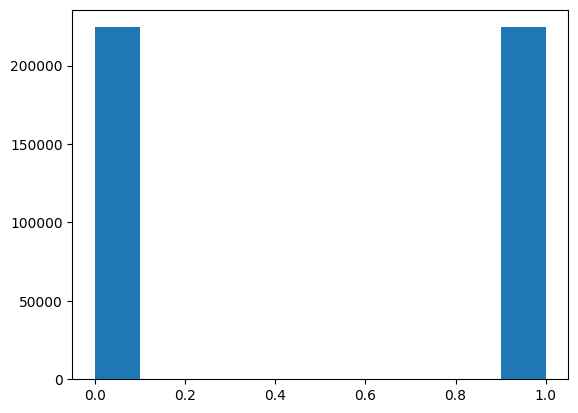

In [ ]:
plt.hist(df['HadHeartAttack'])
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448858 entries, 0 to 448857
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 448858 non-null  int64  
 1   State                      448858 non-null  int64  
 2   Sex                        448858 non-null  int64  
 3   GeneralHealth              448858 non-null  int64  
 4   AgeCategory                448858 non-null  int64  
 5   HeightInMeters             448858 non-null  float64
 6   WeightInKilograms          448858 non-null  float64
 7   BMI                        448858 non-null  float64
 8   HadAngina                  448858 non-null  int64  
 9   HadStroke                  448858 non-null  int64  
 10  HadAsthma                  448858 non-null  int64  
 11  HadSkinCancer              448858 non-null  int64  
 12  HadCOPD                    448858 non-null  int64  
 13  HadDepressiveDisorder      44

In [ ]:
df['SmokerStatus'].unique()

array([1, 2, 3, 4])

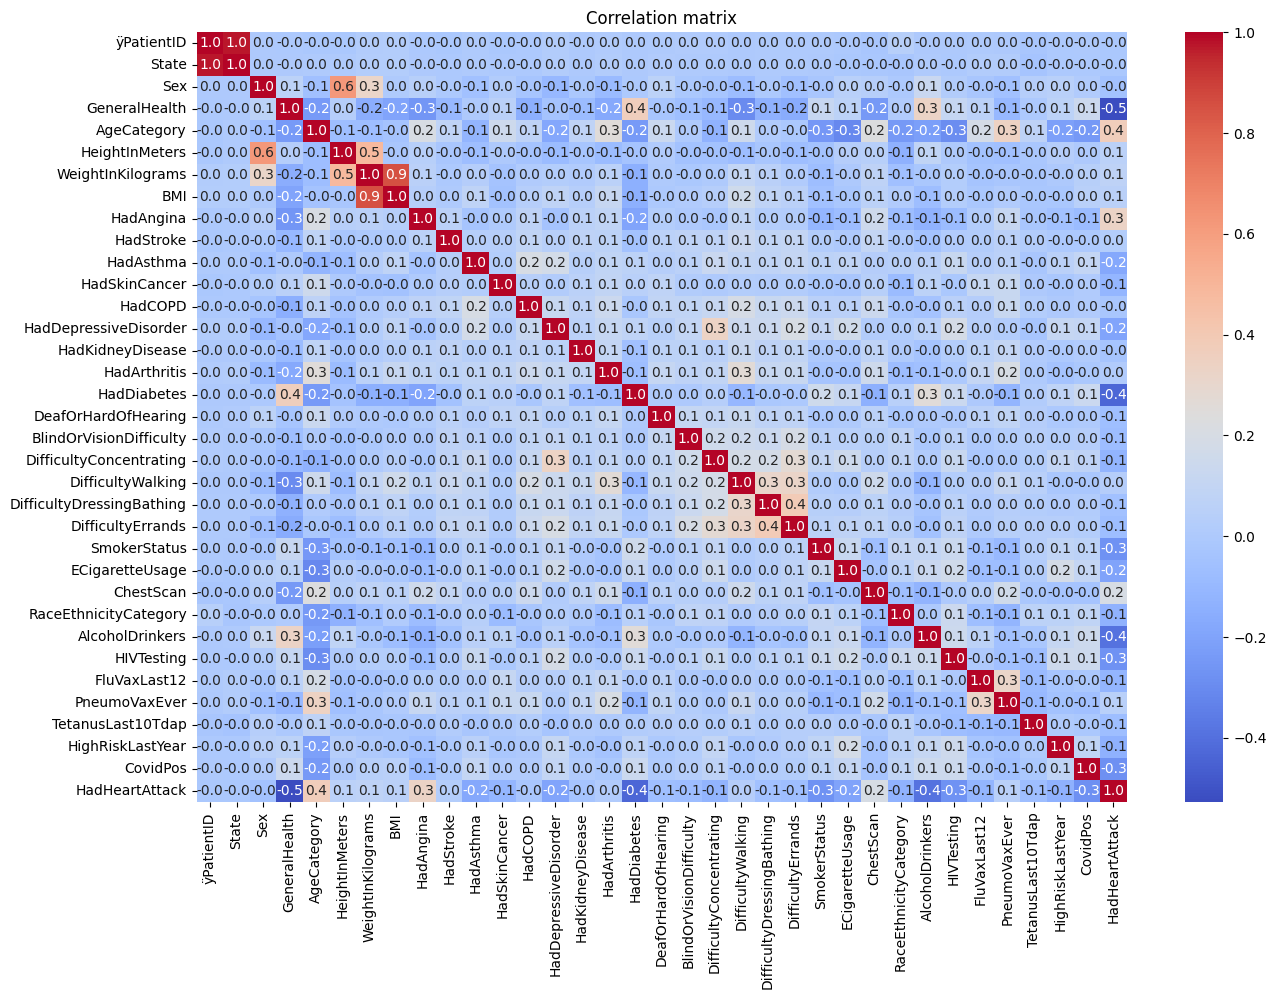

In [ ]:
corr_matrix=df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()


In [ ]:
df.drop(["ÿPatientID","State","WeightInKilograms"],axis=1,inplace=True)

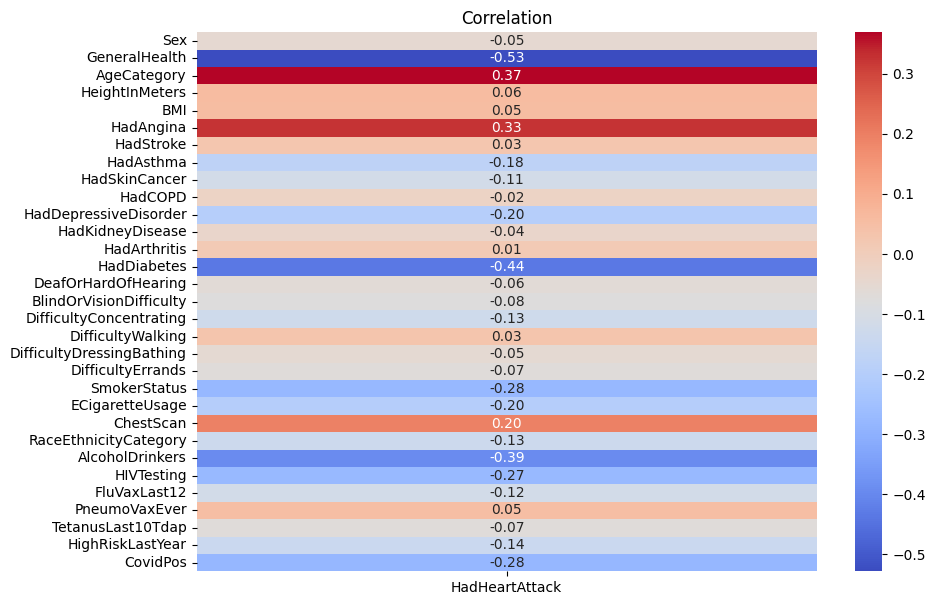

In [ ]:
heart_corr=df.corr() ["HadHeartAttack"]
heart_corr=heart_corr.drop('HadHeartAttack')
plt.figure(figsize=(10,7))
sns.heatmap(heart_corr.to_frame(),annot=True,fmt='0.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title("Correlation")
plt.show()

In [ ]:
df.drop(["Sex","HeightInMeters","BMI","HadStroke","HadCOPD","HadKidneyDisease","HadArthritis","DeafOrHardOfHearing","DifficultyWalking","DifficultyDressingBathing","PneumoVaxEver"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448858 entries, 0 to 448857
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   GeneralHealth            448858 non-null  int64
 1   AgeCategory              448858 non-null  int64
 2   HadAngina                448858 non-null  int64
 3   HadAsthma                448858 non-null  int64
 4   HadSkinCancer            448858 non-null  int64
 5   HadDepressiveDisorder    448858 non-null  int64
 6   HadDiabetes              448858 non-null  int64
 7   BlindOrVisionDifficulty  448858 non-null  int64
 8   DifficultyConcentrating  448858 non-null  int64
 9   DifficultyErrands        448858 non-null  int64
 10  SmokerStatus             448858 non-null  int64
 11  ECigaretteUsage          448858 non-null  int64
 12  ChestScan                448858 non-null  int64
 13  RaceEthnicityCategory    448858 non-null  int64
 14  AlcoholDrinkers          448858 non-

<Axes: >

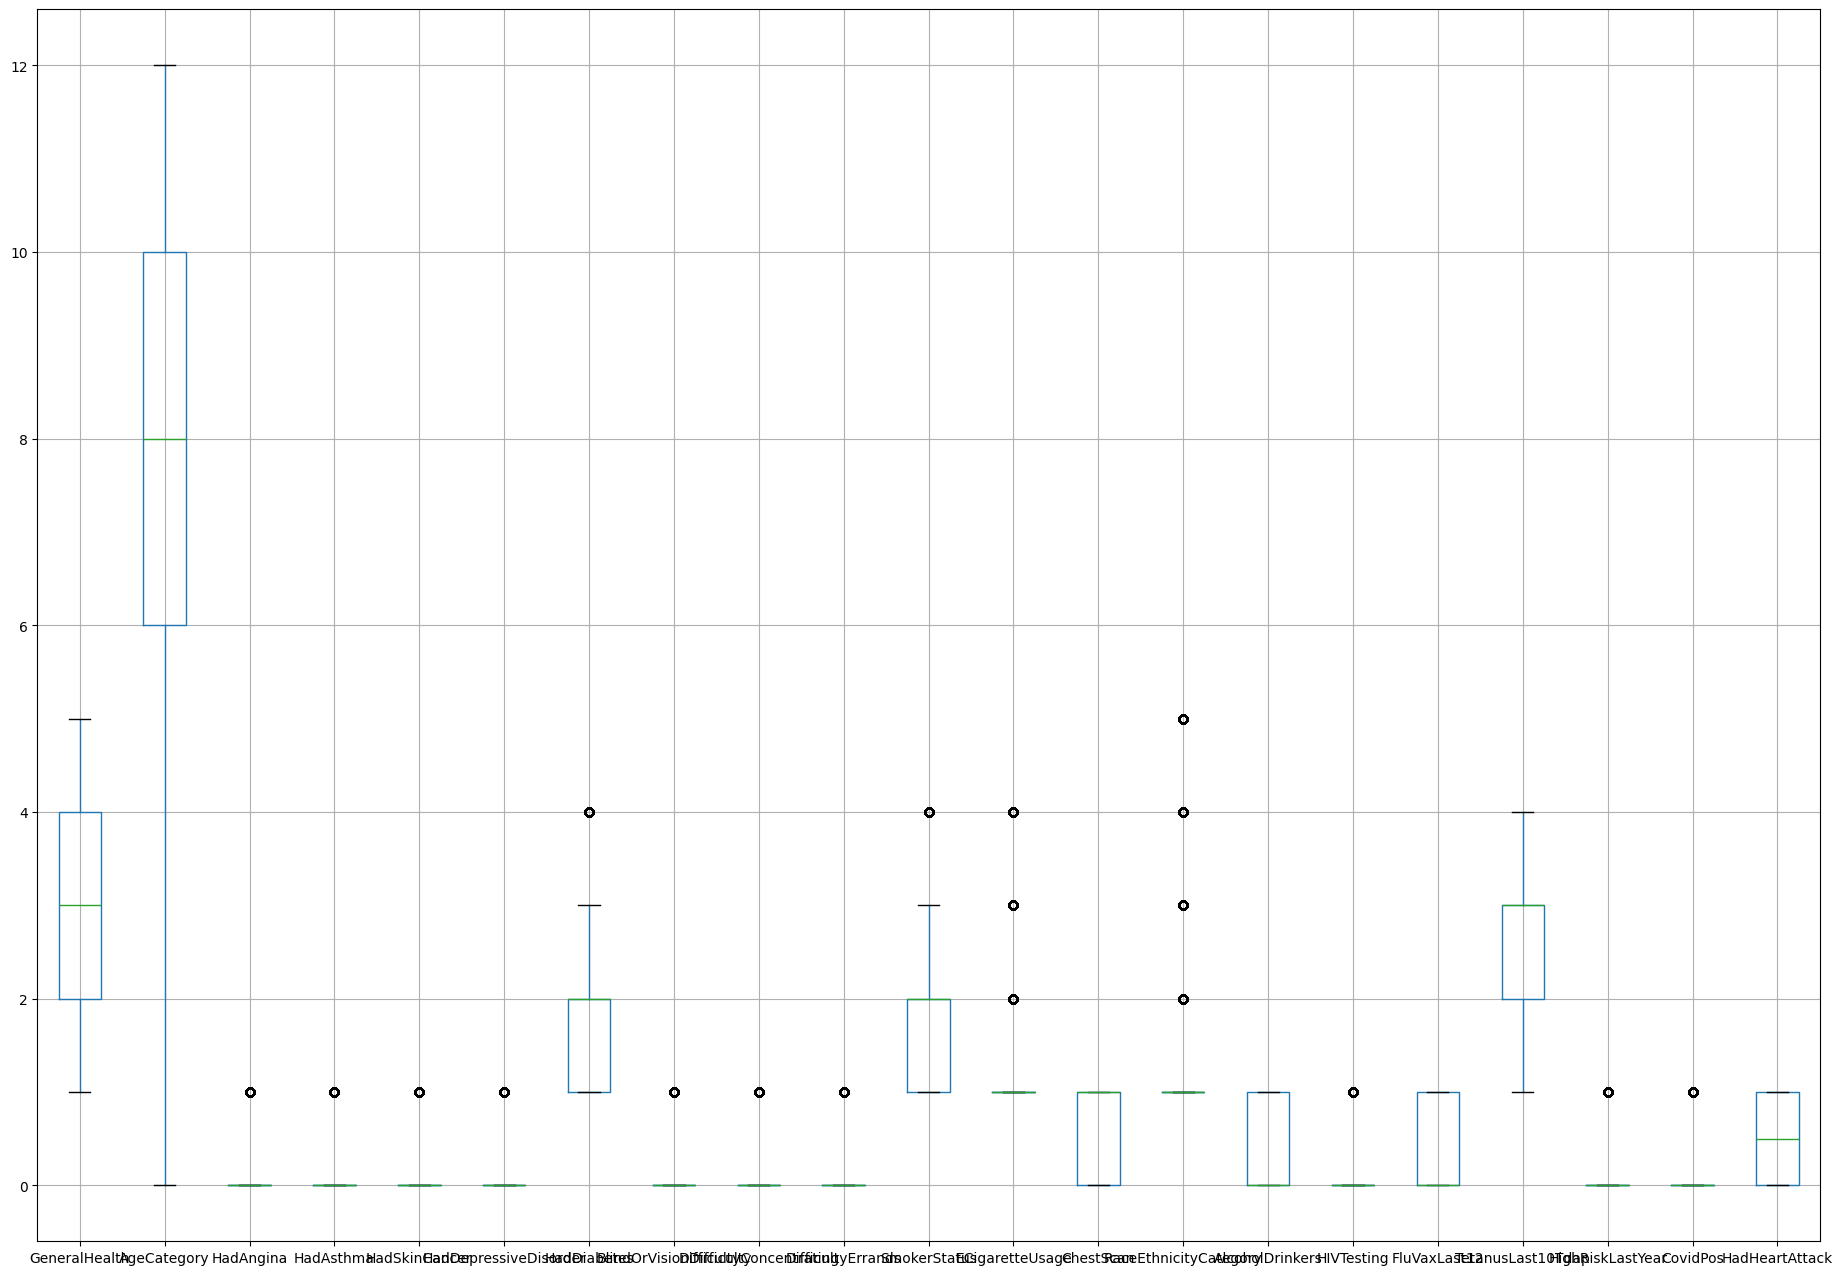

In [ ]:
plt.figure(figsize=(23,16))
df.boxplot()


In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    Q1=df[col].quantile(0.25)
    Q2=df[col].quantile(0.75)
    IQR=Q2-Q1
    lb=Q1-1.5*IQR
    ub=Q2+1.5*IQR
    df=df[(df[col]>=lb)& (df[col]<=ub)]
  return df
cleaned_df=remove_outliers_iqr(df,'HadHeartAttack')
df=cleaned_df

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
X=df.drop("HadHeartAttack",axis=1)
Y=df[["HadHeartAttack"]]
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.25,random_state=42)
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline model accuracy:{accuracy:.2f}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Baseline model accuracy:0.87


In [ ]:
from sklearn.tree import DecisionTreeClassifier
m=DecisionTreeClassifier()
m.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.8693131809766609

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)
model.score(X_test,y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.8821208534401651

In [ ]:
from sklearn.svm import SVC
v=SVC()
v.fit(X_train,y_train)
v.score(X_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8779325624449907

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model=Sequential()
model.add(Dense(128,input_shape=(20,),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
model.fit(X_train,y_train,epochs=30,batch_size=32)

Epoch 1/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8516 - loss: 0.3473
Epoch 2/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8749 - loss: 0.2995
Epoch 3/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8758 - loss: 0.2953
Epoch 4/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8777 - loss: 0.2933
Epoch 5/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8786 - loss: 0.2937
Epoch 6/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8766 - loss: 0.2929
Epoch 7/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8793 - loss: 0.2897
Epoch 8/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8793 - loss: 0.2888
Epoch 9/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8794 - loss: 0.2883
Epoch 10/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8821 - loss: 0.2853
Epoch 11/30
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8814 - loss: 0.2861
Epoch 12/30
3089/3089 ━━━━━

In [ ]:
loss,accuracy=model.evaluate(X_test,y_test)
print(f'Model Accuracy:{accuracy*100:.2f}%')

1030/1030 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8815 - loss: 0.2867
Model Accuracy:88.17%


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

In [ ]:
x=df.drop('HadHeartAttack',axis=1)
y=df['HadHeartAttack']
kf=KFold(n_splits=5,shuffle=True,random_state=42)
model=LogisticRegression()
best_accuracy=0
best_fold=-1
best_x_train=None
best_x_test=None
best_y_train=None
best_y_test=None
best_y_pred=None
for fold,(train_index,test_index) in enumerate(kf.split(x),1):
  x_train,x_test=x.iloc[train_index],x.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  print(f"Fold {fold} Accuracy {acc}")
  if acc>best_accuracy:
    best_accuracy = acc
    best_fold = fold
    best_X_train = x_train
    best_y_train = y_train
    best_X_test = x_test
    best_y_test = y_test
    best_y_pred = y_pred
print(f"\n Best Fold {best_fold} with Accuracy {best_accuracy}")

Fold 1 Accuracy 0.8684320345991882
Fold 2 Accuracy 0.8735536249478356
Fold 3 Accuracy 0.8666489624037331
Fold 4 Accuracy 0.8689581910615373
Fold 5 Accuracy 0.8636087715304651

 Best Fold 2 with Accuracy 0.8735536249478356


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.8842899958268523

In [ ]:
from sklearn.svm import SVC
sv=SVC()
sv.fit(best_X_train,best_y_train)
sv.score(best_X_test,best_y_test)

0.8825448613376835

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model=Sequential()
model.add(Dense(128,input_shape=(20,),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
model.fit(best_X_train,best_y_train,epochs=40,batch_size=32)

Epoch 1/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8548 - loss: 0.3469
Epoch 2/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8737 - loss: 0.3011
Epoch 3/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8757 - loss: 0.3014
Epoch 4/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8766 - loss: 0.2954
Epoch 5/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8768 - loss: 0.2966
Epoch 6/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8790 - loss: 0.2918
Epoch 7/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8791 - loss: 0.2927
Epoch 8/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8774 - loss: 0.2926
Epoch 9/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8782 - loss: 0.2933
Epoch 10/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8791 - loss: 0.2913
Epoch 11/40
3295/3295 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8773 - loss: 0.2933
Epoch 12/40
3295/3295 

In [ ]:
loss,accuracy=model.evaluate(best_X_test,best_y_test)
print(f'Model Accuracy:{accuracy*100:.2f}%')

824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8230 - loss: 0.3933
Model Accuracy:88.58%


In [ ]:
import pickle
with open("Heart DLmodel.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/Heart DLmodel.pkl","rb") as file:
  load_model=pickle.load(file)

### **Conclusion**

In this project, a predictive model was developed to determine whether a patient has experienced a heart attack using **HadHeartAttack** as the target variable. The problem was treated as a binary classification task using patient demographic, lifestyle, and medical features. After training and testing multiple models, the **Deep Learning model achieved the best accuracy** compared to the other algorithms.

The final model was saved in **pickle format** and successfully loaded for future use, making it suitable for deployment without retraining. The results show that machine learning and deep learning techniques can effectively identify patterns in patient data and help predict heart attack risk, which may support early detection and preventive healthcare decisions.
